# Wakefield kick and loss factors for Elettra

This notebook adapts Sara Dastan’s simulation of beam coupling impedances for Elettra Synchrotron. It uses her four STL solids to model a vacuum chamber and three conducting shells. An off-axis bunch excites wakefields; Wakis calculates the longitudinal and transverse wake potentials and impedances, then the bunch loss and kick factors.

The geometry is in `data/001d_*.stl`. The **133 × 160 × 940** grid and 10 m wake length require substantial memory and runtime, so the notebook reduces the original grid by a factor 8. Results are written to `001d_results/`. Run the cells in order.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

from wakis import GridFIT3D, SolverFIT3D, WakeSolver

# Works when the notebook is launched from either notebooks/ or the repository root.
data_dir = Path("data") if Path("data").is_dir() else Path("notebooks/data")
results = Path("001d_results")
results.mkdir(exist_ok=True)

## Geometry and materials

The STL solids are Sara Dastan’s chamber component and three shells. Their coordinates are already in metres. The chamber is vacuum; the shells use the PEC material setting from her simulation.


In [2]:
stl_solids = {
    "cavity": str(data_dir / "001d_component.stl"),
    "shell1": str(data_dir / "001d_shell1.stl"),
    "shell2": str(data_dir / "001d_shell2.stl"),
    "shell3": str(data_dir / "001d_shell3.stl"),
}
stl_materials = {
    "cavity": "vacuum",
    "shell1": "pec",
    "shell2": "pec",
    "shell3": "pec",
}
stl_scale = {name: 1.0 for name in stl_solids}
stl_rotate = {name: (0.0, 0.0, 0.0) for name in stl_solids}
stl_translate = {name: (0.0, 0.0, 0.0) for name in stl_solids}

meshes = {name: pv.read(path) for name, path in stl_solids.items()}
for name, mesh in meshes.items():
    print(f"{name}: {mesh.bounds}")
bounds = (
    meshes["cavity"] + meshes["shell1"] + meshes["shell2"] + meshes["shell3"]
).bounds

cavity: BoundsTuple(x_min = -0.013473604805767536,
            x_max =  0.013473604805767536,
            y_min = -0.008499973453581333,
            y_max =  0.008499973453581333,
            z_min =  1.9999999494757503e-05,
            z_max =  0.093019999563694)
shell1: BoundsTuple(x_min = -0.014962268993258476,
            x_max =  0.014962268993258476,
            y_min = -0.009999973699450493,
            y_max =  0.009999973699450493,
            z_min =  1.9999999494757503e-05,
            z_max =  0.093019999563694)
shell2: BoundsTuple(x_min = -0.006493454799056053,
            x_max =  0.006493454799056053,
            y_min = -0.008500000461935997,
            y_max = -0.001500000013038516,
            z_min =  0.040026165544986725,
            z_max =  0.05299999937415123)
shell3: BoundsTuple(x_min = -0.006493454799056053,
            x_max =  0.006493454799056053,
            y_min =  0.001500000013038516,
            y_max =  0.008500000461935997,
            z_min =  0.04

In [3]:
plotter = pv.Plotter()
for name, mesh in meshes.items():
    plotter.add_mesh(mesh, name=name, opacity=0.3 if name == "cavity" else 0.5)
plotter.show()

Widget(value='<iframe src="http://localhost:41219/index.html?ui=P_0x7e9bf810a790_0&reconnect=auto" class="pyvi…

 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler
 JS Error => TypeError: Cannot create proxy with a non-object as target or handler


## Grid and bunch

The bunch has a 4.5 mm longitudinal RMS size and 1 nC charge. Its source is displaced by 1 mm in $y$; the wake is sampled on axis. The original mesh size and 75 skipped boundary cells are used, but divided by a factor 2 to keep the memory and computational time within 20'. This notebook runs the solver in one process; the same model can be distributed with Wakis’s MPI workflow when more memory or CPU capacity is needed.


In [4]:
Nx, Ny, Nz = 133 // 2, 160 // 2, 940 // 2
sigmaz = 4.5e-3  # m
q = 1e-9  # C
beta = 1.0  # relativistic beta factor
xs, ys = 0.0, 1e-3  # source position [m]
xt, yt = 0.0, 0.0  # test position [m]
wakelength = 10.0  # m
skip_cells = 75 // 2

grid = GridFIT3D(
    *bounds,
    Nx,
    Ny,
    Nz,
    use_mpi=False,  # Turn true for the full resolution simulation
    stl_solids=stl_solids,
    stl_materials=stl_materials,
    stl_scale=stl_scale,
    stl_rotate=stl_rotate,
    stl_translate=stl_translate,
    stl_method="voxelize_rectilinear",
    verbose=1,
)
wake = WakeSolver(
    q=q,
    sigmaz=sigmaz,
    beta=beta,
    xsource=xs,
    ysource=ys,
    xtest=xt,
    ytest=yt,
    skip_cells=skip_cells,
    results_folder=str(results),
    Ez_file=str(results / "Ez.h5"),
    save=True,
)

Generating grid with 2481600 mesh cells...
Importing STL solids...
 * Marking cells inside STL solid 'cavity'...
    * STL solid cavity: 1216830 cells marked inside the solid.
 * Marking cells inside STL solid 'shell1'...
    * STL solid shell1: 445560 cells marked inside the solid.
 * Marking cells inside STL solid 'shell2'...
    * STL solid shell2: 41300 cells marked inside the solid.
 * Marking cells inside STL solid 'shell3'...
    * STL solid shell3: 41300 cells marked inside the solid.
Total grid initialization time: 0.32187819480895996 s
Initializing Wakefield parameters...
Total solver initialization time: 7.486343383789062e-05 s


In [5]:
# Inspect the imported solids with the materials
grid.plot_solids()

Widget(value='<iframe src="http://localhost:41219/index.html?ui=P_0x7e9bfc880cd0_1&reconnect=auto" class="pyvi…

In [6]:
# Inspect the generated grid
grid.inspect()

Widget(value='<iframe src="http://localhost:41219/index.html?ui=P_0x7e9acd8e6990_2&reconnect=auto" class="pyvi…

In [7]:
grid.plot_stl_mask_slice("cavity", plane="XY")  # or shell1, shell2, shell3

Widget(value='<iframe src="http://localhost:41219/index.html?ui=P_0x7e9acd8e7f90_3&reconnect=auto" class="pyvi…

## Run the wakefield simulation

The CPU solver uses double precision and PEC boundaries across the pipe, with PML boundaries at its two longitudinal ends. The 10 m wake has been shortened to 1m for a quicker first calculation, without live plots.


In [8]:
solver = SolverFIT3D(
    grid,
    wake,
    bc_low=["pec", "pec", "pml"],
    bc_high=["pec", "pec", "pml"],
    use_stl=True,
    use_mpi=False,  # Turn true for multi-process simulation
    use_gpu=False,  # Turn true if your computer has a GPU and cupy installed
    dtype=np.float32,  # Change to np.float64 for higher precision / slower
    cfln=0.8,
    n_pml=8,
    bg="vacuum",
    verbose=2,
)

solver.inspect()

Initializing Electromagnetic solver...
    * Maximum frequency set to fmax=22.206848740740746 GHz
Assembling operator matrices...
Applying boundary conditions...
Adding material tensors...
    * Max resolved conductivity without SIBC: 1456.6431003786893 S/m
Filling PML sigmas...
    * PML thickness: 8 cells
Calculating maximal stable timestep...
    * Simulation timestep: dt=3.917e-13 s
    * Total simulation time for wakelength=1.0 m: tmax=3.774e-09 s
    * Total number of timesteps for wakelength=1.0 m: Nt=9632
Pre-computing...
Using MKL backend for time-stepping...
Total solver initialization time: 3.4572999477386475 s


Widget(value='<iframe src="http://localhost:41219/index.html?ui=P_0x7e9bf81cc490_4&reconnect=auto" class="pyvi…

In [9]:
solver.wakesolve(
    wakelength=wakelength // 10,
    plot=False,
)

Running electromagnetic time-domain simulation...


100%|██████████| 9632/9632 [11:15<00:00, 14.25it/s]


Reading h5 file 001d_results/Ez.h5
Size of the h5 file: 0.17 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 79587/79587 [00:23<00:00, 3347.10it/s]


Elapsed time 23.77821922302246 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 79587/79587 [00:00<00:00, 269147.07it/s]


Elapsed time 0.2962183952331543 s
Calculating longitudinal impedance Z...
[!] Using analytic charge distribution λ(s) since no data was provided
Calculating transverse impedance Zx, Zy...
Calculation terminated in 24s


In [18]:
wake = WakeSolver(
    q=q,
    sigmaz=sigmaz,
    beta=beta,
    xsource=xs,
    ysource=ys,
    xtest=xt,
    ytest=yt,
    skip_cells=skip_cells,
    results_folder=str(results),
    Ez_file=str(results / "Ez.h5"),
    save=True,
)
wake.solve()

Initializing Wakefield parameters...
Total solver initialization time: 0.0011203289031982422 s
Reading h5 file 001d_results/Ez.h5
Size of the h5 file: 0.17 Gb
Calculating longitudinal wake potential WP(s)


100%|██████████| 79578/79578 [00:26<00:00, 3054.23it/s]


Elapsed time 26.05554962158203 s
Calculating transverse wake potential WPx, WPy...


100%|██████████| 79578/79578 [00:00<00:00, 290391.31it/s]


Elapsed time 0.2743821144104004 s
Calculating longitudinal impedance Z...
[!] Using analytic charge distribution λ(s) since no data was provided
Calculating transverse impedance Zx, Zy...
Calculation terminated in 26s


## Wake potentials and impedances

The left column shows the longitudinal and transverse wake potentials. The right column shows the magnitudes of their impedances. Distance is in centimetres and frequency in gigahertz.


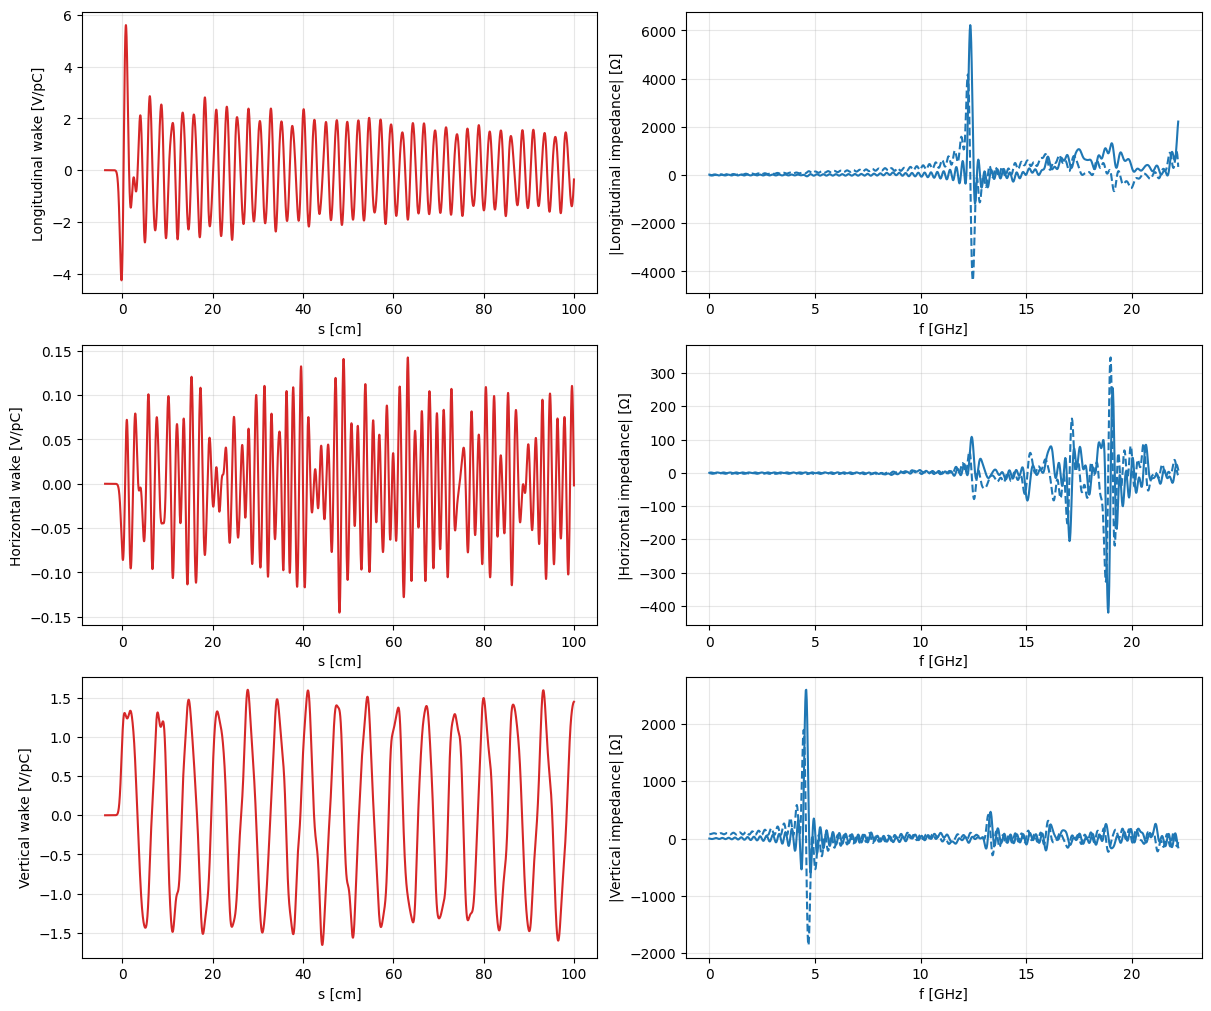

In [19]:
%matplotlib inline 
# change to ipympl for interactive

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
components = (
    ("Longitudinal", wake.WP, wake.f, wake.Z),
    ("Horizontal", wake.WPx, wake.fx, wake.Zx),
    ("Vertical", wake.WPy, wake.fy, wake.Zy),
)
for row, (name, potential, frequency, impedance) in enumerate(components):
    axes[row, 0].plot(wake.s * 1e2, potential, c='tab:red')
    axes[row, 0].set(xlabel="s [cm]", ylabel=f"{name} wake [V/pC]")
    axes[row, 0].grid(alpha=0.3)
    #axes[row, 1].plot(frequency * 1e-9, np.abs(impedance), c='tab:blue' )
    axes[row, 1].plot(frequency * 1e-9, np.real(impedance), c='tab:blue')
    axes[row, 1].plot(frequency * 1e-9, np.imag(impedance), ls='--', c='tab:blue')
    axes[row, 1].set(xlabel="f [GHz]", ylabel=f"|{name} impedance| [Ω]")
    axes[row, 1].grid(alpha=0.3)
plt.show()

## Bunch loss and kick factors

`WakeSolver` weights the wakes by the bunch profile. Factors retain their signs. The vertical kick factor is divided by the 1 mm source displacement; the horizontal factor is undefined for the zero horizontal displacement. The methods also save `loss_factor.txt` and `kick_factors.txt` in the results directory.


In [11]:
loss_factor = wake.calc_loss_factor()
kick_x, kick_y = wake.calc_kick_factors()

print(f"Signed loss factor: {loss_factor:.6g} V/pC")
print(f"Horizontal kick factor: {kick_x} (zero horizontal source offset)")
print(f"Signed vertical kick factor: {kick_y:.6g} V/pC/m")

Signed loss factor: -1.08937 V/pC
Horizontal kick factor: None (zero horizontal source offset)
Signed vertical kick factor: 900.22 V/pC/m


## Longitudinal impedance of the causal wake

Sara’s postprocessing also selects $0 \leq s \leq 10$ m and recalculates the longitudinal impedance up to 23 GHz with 4097 samples. This step runs after the factor calculation because `calc_long_Z` replaces the wake arrays passed as arguments.


Calculating longitudinal impedance Z...


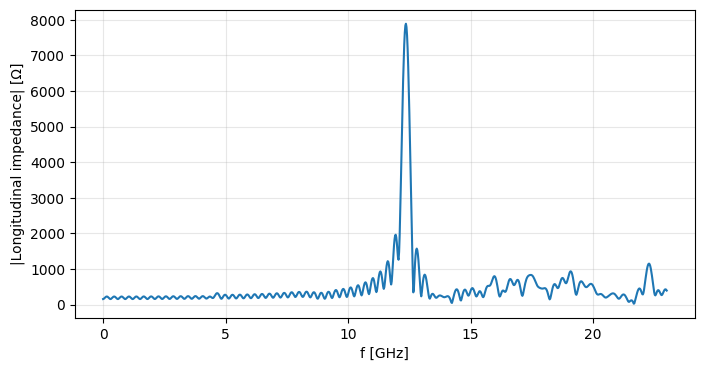

In [ ]:
mask = (wake.s >= 0.0) & (wake.s <= wakelength)
wake.calc_long_Z(
    samples=4097,
    fmax=23e9,
    WP=wake.WP[mask],
    s=wake.s[mask],
    lambdas=wake.lambdas[mask],
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wake.f * 1e-9, np.abs(wake.Z))
ax.set(xlabel="f [GHz]", ylabel="|Longitudinal impedance| [Ω]")
ax.grid(alpha=0.3)
plt.show()

In [ ]:
# The original results can be recomputed by
wake.reset() # Sets to None all computed values
wake.solve() # Re-runs the wake post-processing